In [72]:
import sys

sys.path.append("..")

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import random
from pulp import *
import cma

In [73]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
    plot_lp_result,
    plot_lp_swap_result,
)

from calculation.calculation import find_farthest_pair, find_farthest_triple

from lp.lp import PermutationLpModel, exclude_current_solution, exclude_largest_variable

In [74]:
# https://claude.ai/share/38d5e708-a9f6-456d-b1f1-69be59d9f84c

Genom to ciąg liczb opisujących całe wybory. Genom składa się z dwóch częsci.
1. $m$ kandydatów, dla każdego para współrzędnych $(x,y)$, więc razem $2m$ zmiennych
2. $G$ skupisk, gdzie każde skupisko opisane jest czterema liczbami: położeniem środka $(x,y)$, rozrzutem i wagą. Łącznie $4G$ zmiennych.

Łącznie jeden genom jest $(2m+4G)$ wymiarowy.

In [75]:
@dataclass
class GenomeConfig:
    n_candidates: int
    n_clusters: int
    bounds_x: tuple[float, float] = (-10.0, 10.0)
    bounds_y: tuple[float, float] = (-10.0, 10.0)
    spread_bounds: tuple[float, float] = (0.5, 5.0)
    weight_bounds: tuple[float, float] = (0.0, 1.0)

    @property
    def genome_length(self) -> int:
        return 2 * self.n_candidates + 4 * self.n_clusters

    @property
    def lower_bounds(self) -> list[float]:
        candidate_lb = [self.bounds_x[0], self.bounds_y[0]] * self.n_candidates
        cluster_lb = [
            self.bounds_x[0],
            self.bounds_y[0],
            self.spread_bounds[0],
            self.weight_bounds[0],
        ] * self.n_clusters
        return candidate_lb + cluster_lb

    @property
    def upper_bounds(self) -> list[float]:
        candidate_ub = [self.bounds_x[1], self.bounds_y[1]] * self.n_candidates
        cluster_ub = [
            self.bounds_x[1],
            self.bounds_y[1],
            self.spread_bounds[1],
            self.weight_bounds[1],
        ] * self.n_clusters
        return candidate_ub + cluster_ub

    def random_genome(self, rng: np.random.Generator) -> np.ndarray:
        lb = np.array(self.lower_bounds)
        ub = np.array(self.upper_bounds)
        return lb + rng.random(self.genome_length) * (ub - lb)


@dataclass
class VoterCluster:
    center: tuple[float, float]
    spread: float
    weight: float


def decode_genome(
    genome: np.ndarray, config: GenomeConfig
) -> tuple[list[Candidate], list[VoterCluster]]:
    genome = np.asarray(genome)
    n_candidate_genes = 2 * config.n_candidates

    candidate_genes = genome[:n_candidate_genes]
    candidates = [
        Candidate(id=i, position=(candidate_genes[2 * i], candidate_genes[2 * i + 1]))
        for i in range(config.n_candidates)
    ]

    cluster_genes = genome[n_candidate_genes:]
    clusters = [
        VoterCluster(
            center=(cluster_genes[4 * g], cluster_genes[4 * g + 1]),
            spread=max(cluster_genes[4 * g + 2], 1e-3),
            weight=max(cluster_genes[4 * g + 3], 0.0),
        )
        for g in range(config.n_clusters)
    ]

    return candidates, clusters


def generate_voters(
    clusters: list[VoterCluster], n_voters: int, rng: np.random.Generator
) -> list[Voter]:
    weights = np.array([c.weight for c in clusters])
    if weights.sum() <= 0:
        weights = np.ones(len(clusters))
    probs = weights / weights.sum()

    cluster_choices = rng.choice(len(clusters), size=n_voters, p=probs)
    voters = []
    for idx in cluster_choices:
        cluster = clusters[idx]
        position = rng.normal(loc=cluster.center, scale=cluster.spread, size=2)
        voters.append(Voter(position=position))
    return voters


Rozważ odporniejszą metrykę - np. karę za kandydatów na brzegu albo niezgodę względem rozrzutu kandydatów - żeby optimum nie było po prostu "rogi planszy".

In [76]:
# Objective functions for the CMA-ES search. Each maps an ElectionResult to a
# scalar to MAXIMISE.


def _mean_pairwise(points: np.ndarray) -> float:
    """Average Euclidean distance over all unordered pairs of points."""
    if len(points) < 2:
        return 0.0
    d = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2)
    return float(d[np.triu_indices(len(points), k=1)].mean())


def _spread(points: np.ndarray) -> float:
    """Scale proxy: RMS distance to the centroid. O(n), so cheap for many voters."""
    if len(points) < 2:
        return 0.0
    return float(np.sqrt(((points - points.mean(axis=0)) ** 2).sum(axis=1).mean()))


def winner_disagreement(result: ElectionResult) -> float:
    """Original objective: mean pairwise distance between the rules' winners. Its
    optimum is degenerate -- it just pushes candidates to the board corners."""
    winners = np.array([w.position for w in result.winners().values()])
    return _mean_pairwise(winners)


def relative_winner_disagreement(
    result: ElectionResult, denominator: str = "voters", eps: float = 1e-9
) -> float:
    """Scale-free disagreement: winner spread divided by the field's spread, so
    blowing everything up to the corners no longer helps (the ratio is homogeneous
    of degree 0). The optimiser must make winners far apart *relative* to the field.

    denominator: "voters" (spread of the electorate; hardest to game) or
                 "candidates" (spread of the candidate field).
    """
    winners = np.array([w.position for w in result.winners().values()])
    numerator = _mean_pairwise(winners)
    if denominator == "candidates":
        field = np.array([c.position for c in result.candidates])
    else:
        field = np.array([v.position for v in result.voters])
    return numerator / (_spread(field) + eps)

In [77]:
def evaluate_genome(
    genome: np.ndarray,
    config: GenomeConfig,
    strategies: list[VotingStrategy],
    n_voters: int,
    rng: np.random.Generator,
    n_reps: int = 1,
    objective=relative_winner_disagreement,
) -> float:
    """Averaging denoises the stochastic fitness so the optimizer ranks
    genomes by their *true* value, not by a lucky voter sample."""
    candidates, clusters = decode_genome(genome, config)
    scores = []
    for _ in range(n_reps):
        voters = generate_voters(clusters, n_voters, rng)
        result = Election(candidates, voters).compare_strategies(strategies)
        scores.append(objective(result))
    return float(np.mean(scores))


class EvolutionaryElection:
    def __init__(
        self,
        config: GenomeConfig,
        strategies: list[VotingStrategy],
        n_voters: int = 200,
        sigma0: float = 2.0,
        seed: int | None = None,
        popsize: int | None = None,
        n_reps: int = 3,
        objective=relative_winner_disagreement,
    ):
        self.config = config
        self.strategies = strategies
        self.n_voters = n_voters
        self.n_reps = n_reps
        self.objective = objective
        self.rng = np.random.default_rng(seed)

        x0 = config.random_genome(self.rng)
        ranges = np.array(config.upper_bounds) - np.array(config.lower_bounds)
        opts = {
            "bounds": [config.lower_bounds, config.upper_bounds],
            "seed": seed if seed is not None else np.nan,
            # Per-dimension scale so a single sigma0 makes sense across genes with
            # very different ranges (positions vs. spread vs. weight).
            "CMA_stds": (ranges / ranges.max()).tolist(),
        }
        if popsize is not None:
            opts["popsize"] = popsize

        self.es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
        self.history: list[float] = []

    def _fitness(self, genome: np.ndarray) -> float:
        score = evaluate_genome(
            genome,
            self.config,
            self.strategies,
            self.n_voters,
            self.rng,
            self.n_reps,
            self.objective,
        )
        # cma minimizes, but we want to maximize the disagreement between strategies
        return -score

    def step(self) -> float:
        solutions = self.es.ask()
        fitnesses = [self._fitness(np.array(x)) for x in solutions]
        self.es.tell(solutions, fitnesses)
        best = -min(fitnesses)
        self.history.append(best)
        return best

    def run(self, n_generations: int = 50, verbose: bool = False) -> np.ndarray:
        for gen in range(n_generations):
            best = self.step()
            if verbose:
                print(f"gen {gen:3d}: best objective = {best:.4f}")
        return self.best_genome()

    def best_genome(self) -> np.ndarray:
        return np.array(self.es.result.xbest)

    def best_election(self) -> Election:
        candidates, clusters = decode_genome(self.best_genome(), self.config)
        voters = generate_voters(clusters, self.n_voters, self.rng)
        return Election(candidates, voters)

In [78]:
config = GenomeConfig(n_candidates=5, n_clusters=4)
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]

evo = EvolutionaryElection(
    config,
    strategies,
    n_voters=1000,
    sigma0=2.0,
    objective=relative_winner_disagreement,  # scale-free; use winner_disagreement to revert
)
evo.run(n_generations=25, verbose=True)

best_election = evo.best_election()
best_result = best_election.compare_strategies(strategies, label="best genome")
best_result.winners()

(6_w,13)-aCMA-ES (mu_w=4.0,w_1=38%) in dimension 26 (seed=nan, Sun Jun 21 22:52:33 2026)
gen   0: best objective = 1.6144
gen   1: best objective = 1.0356
gen   2: best objective = 1.3637
gen   3: best objective = 1.4174
gen   4: best objective = 1.4941
gen   5: best objective = 1.3112
gen   6: best objective = 1.6594
gen   7: best objective = 1.6952
gen   8: best objective = 1.8088
gen   9: best objective = 1.7739
gen  10: best objective = 2.0381
gen  11: best objective = 1.9362
gen  12: best objective = 2.0096
gen  13: best objective = 2.1290
gen  14: best objective = 2.3404
gen  15: best objective = 1.9720
gen  16: best objective = 1.7262
gen  17: best objective = 2.5261
gen  18: best objective = 2.5675
gen  19: best objective = 2.4667
gen  20: best objective = 2.4128
gen  21: best objective = 2.2155
gen  22: best objective = 2.2872
gen  23: best objective = 2.5968
gen  24: best objective = 2.4783


{'plurality': Candidate(id=3, position=(np.float64(8.310257113246196), np.float64(8.706978220328335))),
 'borda': Candidate(id=0, position=(np.float64(-4.250611870849436), np.float64(9.601428684535554))),
 'veto': Candidate(id=1, position=(np.float64(9.695197959095886), np.float64(-7.693082432984411)))}

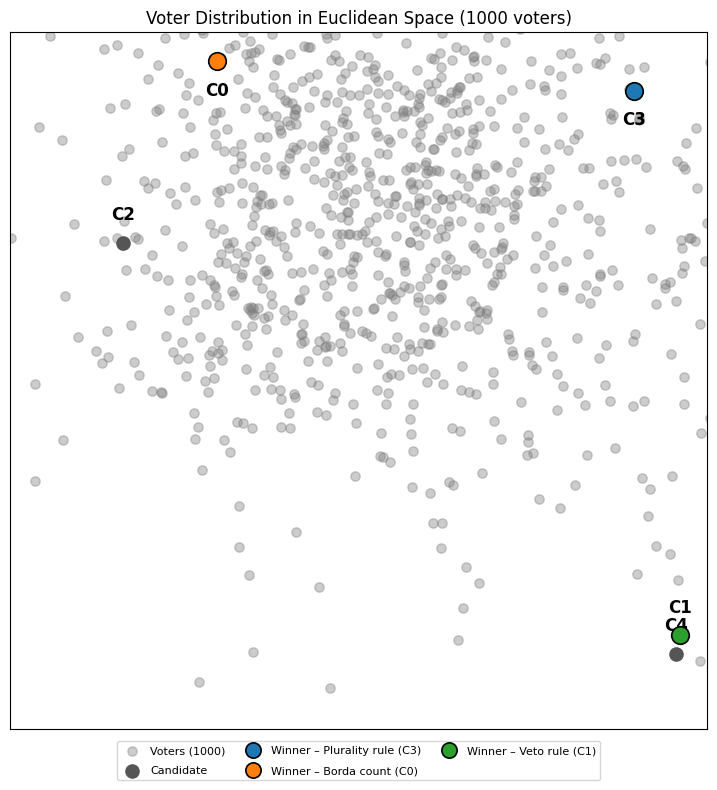

In [79]:
plot_results(best_result)

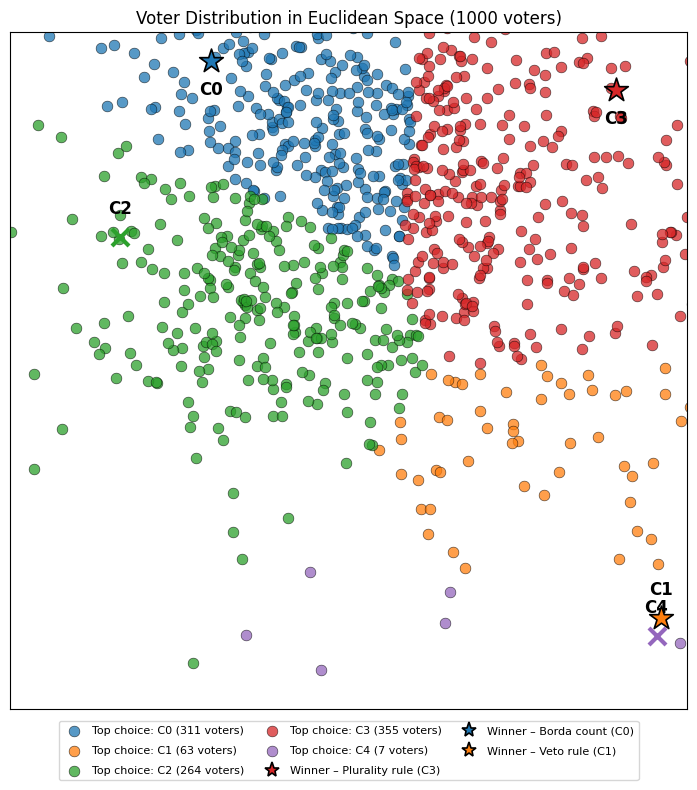

In [80]:
plot_results(best_result, color_voters=True)